In [ ]:
# Project Phase 1

# Joseph Pignatone
# Jordan Deandrade

In [1]:
import pandas as pd

# Load the dataset
file_path = "EV_Charging_Stations_2_Feb82024.csv"
df = pd.read_csv(file_path, encoding="latin1", delimiter=",", quotechar='"', on_bad_lines="skip", low_memory=False)

# Quick preview
df.head()


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,Restricted Access,RD Blends,RD Blends (French),RD Blended with Biodiesel,RD Maximum Biodiesel Level,NPS Unit Name,CNG Station Sells Renewable Natural Gas,LNG Station Sells Renewable Natural Gas,Maximum Vehicle Class,EV Workplace Charging
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,NaN,Sun Valley,CA,91352,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRUE,NaN
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,False
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Across Hope,Los Angeles,CA,90012,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,TRUE,NaN
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,NaN,Long Beach,CA,90803,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRUE,NaN
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,At B St,Wilmington,CA,90744,NaN,NaN,E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TRUE,NaN


In [2]:
# cleaning step 1

# Drop columns with mostly null values or unrelated to electric charging
cols_to_drop = [
    'Plus4', 'Expected Date', 'BD Blends', 'NG Fill Type Code', 'NG PSI',
    'Hydrogen Status Link', 'NG Vehicle Class', 'LPG Primary', 'E85 Blender Pump',
    'Intersection Directions (French)', 'Access Days Time (French)', 'BD Blends (French)',
    'Groups With Access Code (French)', 'CNG Dispenser Num', 'CNG On-Site Renewable Source',
    'CNG Total Compression Capacity', 'CNG Storage Capacity', 'LNG On-Site Renewable Source',
    'EV Pricing (French)', 'LPG Nozzle Types', 'Hydrogen Pressures', 'Hydrogen Standards',
    'CNG Fill Type Code', 'CNG PSI', 'CNG Vehicle Class', 'LNG Vehicle Class',
    'RD Blends', 'RD Blends (French)', 'RD Blended with Biodiesel',
    'RD Maximum Biodiesel Level', 'CNG Station Sells Renewable Natural Gas', 'Intersection Directions',
    'Station Phone', 'Cards Accepted', 'EV Other Info', 'Geocode Status', 'Owner Type Code',
    'Federal Agency ID', 'Federal Agency Name', 'Open Date', 'Hydrogen Is Retail',
    'Access Code', 'Access Detail Code', 'Federal Agency Code', 'Facility Type',
    'E85 Other Ethanol Blends', 'EV Pricing', 'EV On-Site Renewable Source',
    'Restricted Access', 'NPS Unit Name', 'LNG Station Sells Renewable Natural Gas',
    'Maximum Vehicle Class', 'EV Workplace Charging', 'EV Network Web',
    'Access Days Time' 


]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [3]:
# Quick preview
df.head()

,Fuel Type Code,Station Name,Street Address,City,State,ZIP,Status Code,Groups With Access Code,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Network,Latitude,Longitude,Date Last Confirmed,ID,Updated At,EV Connector Types,Country
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,Sun Valley,CA,91352,E,Private,NaN,57.0,2.0,SHELL_RECHARGE,34.248319,-118.3879714,9/14/2023,1517,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015,E,Public,NaN,7.0,NaN,Non-Networked,34.040539,-118.271387,1/10/2023,1523,2023-02-14 15:54:11 UTC,J1772,US
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Los Angeles,CA,90012,E,Private,NaN,338.0,12.0,Non-Networked,34.059133,-118.248589,9/14/2023,1525,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,Long Beach,CA,90803,E,Private,NaN,19.0,1.0,Non-Networked,33.759802,-118.096665,1/9/2024,1531,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,Wilmington,CA,90744,E,Private,NaN,10.0,NaN,Non-Networked,33.770508,-118.265628,1/9/2024,1552,2024-01-31 22:07:01 UTC,J1772,US


In [4]:
# cleaning step 2

df.rename(columns={
    'EV Level1 EVSE Num': 'Level1_Chargers',
    'EV Level2 EVSE Num': 'Level2_Chargers',
    'EV DC Fast Count': 'DC_Fast_Chargers',
    'EV Network': 'EV_Network',
    'EV Connector Types': 'Connector_Types'
}, inplace=True)


In [36]:
# cleaning step 3

# only keep rows where the state is a two letter abbreviation 
df = df[df['State'].notnull() & df['State'].str.match("^[A-Z]{2}$")]


In [6]:
# cleaning step 4 

#  Convert Charger Counts to Numeric
df['Level1_Chargers'] = pd.to_numeric(df['Level1_Chargers'], errors='coerce')
df['Level2_Chargers'] = pd.to_numeric(df['Level2_Chargers'], errors='coerce')
df['DC_Fast_Chargers'] = pd.to_numeric(df['DC_Fast_Chargers'], errors='coerce')


In [7]:
# cleaning step 5

# Remove Duplicate Stations
df.drop_duplicates(subset=['Station Name', 'Street Address', 'City', 'State'], inplace=True)


In [8]:
# cleaning step 6

# Drop rows missing long / lat locations
df = df[df['Latitude'].notnull() & df['Longitude'].notnull()]


In [9]:
# cleaning step 7

# fill missing charger counts with 0
df[['Level1_Chargers', 'Level2_Chargers', 'DC_Fast_Chargers']] = df[[
    'Level1_Chargers', 'Level2_Chargers', 'DC_Fast_Chargers'
]].fillna(0)


In [10]:
# Cleaning step 8

# create total chargers column
df['Total_Chargers'] = df['Level1_Chargers'] + df['Level2_Chargers'] + df['DC_Fast_Chargers']


In [11]:
# cleaning step 9 

# Standardize cases in names
df['EV_Network'] = df['EV_Network'].str.title()
df['City'] = df['City'].str.title()


In [12]:
# cleaning step 10

# Keep only electric vehicle charging stations
# dataset includes multiple types of alternative fuel stations
df = df[df["Fuel Type Code"] == "ELEC"]


In [13]:
df.head(10)       # first 10 rows
df.tail(10)       # last 10 rows
df.sample(10)     # 10 random rows


,Fuel Type Code,Station Name,Street Address,City,State,ZIP,Status Code,Groups With Access Code,Level1_Chargers,Level2_Chargers,DC_Fast_Chargers,EV_Network,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Connector_Types,Country,Total_Chargers
44272,ELEC,Market Basket Biddeford #75,220 Mariner Way,Biddeford,ME,4005,E,Public,0.0,0.0,2.0,Evgo Network,43.472110,-70.51253,2/7/2024,228534,2024-02-07 23:57:10 UTC,CHADEMO J1772COMBO,US,2.0
61794,ELEC,DCM COMPLEX DHS6,1025 Langley St,Fall River,MA,2720,E,Public,0.0,2.0,0.0,Chargepoint Network,41.718790,-71.126586,2/8/2024,322576,2024-02-08 01:26:21 UTC,J1772,US,2.0
34136,ELEC,Goodwill,5980 Krueger Ln,Oak Park Heights,MN,55082,E,Public - Credit card at all times,0.0,2.0,0.0,Non-Networked,45.034895,-92.83918329,11/4/2021,197504,2022-02-10 19:42:29 UTC,J1772,US,2.0
15038,ELEC,DUTCH BROS DIXON 01,1115 Pitt School Rd,Dixon,CA,95620,E,Public,0.0,2.0,0.0,Chargepoint Network,38.455778,-121.840948,2/8/2024,158864,2024-02-08 00:44:23 UTC,J1772,US,2.0
46330,ELEC,POINTE@POLARIS EV STATION 04,8924 Lyra Dr,Columbus,OH,43240,E,Public,0.0,2.0,0.0,Chargepoint Network,40.147330,-82.973858,2/8/2024,235605,2024-02-08 00:34:05 UTC,J1772,US,2.0
57626,ELEC,Overture Dr Phillips station location,7335 W Sand Lake Rd Ste 137,Orlando,FL,32819,E,Public,0.0,4.0,0.0,Blink Network,28.451059,-81.4798071,2/8/2024,309929,2024-02-08 00:07:26 UTC,J1772,US,4.0
25680,ELEC,GA TECH AREA 4 #3,837 State St NW,Atlanta,GA,30313,E,Public,0.0,2.0,0.0,Chargepoint Network,33.777545,-84.399306,2/8/2024,179891,2024-02-08 00:15:27 UTC,J1772,US,2.0
33192,ELEC,Rose Villa,13505 SE River RD,Portland,OR,97222,E,Public,0.0,2.0,0.0,Blink Network,45.425563,-122.6459648,2/8/2024,195503,2024-02-08 00:09:56 UTC,J1772,US,2.0
49648,ELEC,Mountainside Fitness 11611 East Sahuaro Drive ...,11611 East Sahuaro Drive,Scottsdale,AZ,85259,E,Public,0.0,0.0,2.0,Volta,33.584035,-111.829547,2/8/2024,253552,2024-02-08 01:57:28 UTC,J1772COMBO,US,2.0
27843,ELEC,SIMBA_2 SIMBA 45&46,1141 W Katella Ave,Anaheim,CA,92802,E,Public,0.0,2.0,0.0,Chargepoint Network,33.803787,-117.925764,2/8/2024,183222,2024-02-08 00:46:52 UTC,J1772,US,2.0


In [14]:
# Group by state and sum total chargers
chargers_by_state = df.groupby("State")["Total_Chargers"].sum().sort_values(ascending=False)

# Add a new column: total chargers in that state
df["Total_Chargers_in_State"] = df["State"].map(chargers_by_state)

# Display the result
chargers_by_state


State
CA    49387.0
NY    11452.0
FL     9671.0
TX     8804.0
MA     7357.0
WA     5842.0
CO     5422.0
GA     5171.0
MD     5008.0
VA     4528.0
PA     4299.0
NC     4192.0
NJ     3671.0
OH     3603.0
AZ     3486.0
IL     3477.0
MI     3379.0
OR     3153.0
MO     2649.0
CT     2514.0
TN     2170.0
UT     2152.0
NV     2004.0
MN     1993.0
IN     1502.0
WI     1423.0
OK     1341.0
SC     1338.0
DC     1168.0
KS     1160.0
AL     1089.0
ME     1069.0
VT      954.0
IA      829.0
AR      824.0
RI      815.0
KY      809.0
HI      806.0
NM      703.0
LA      698.0
NH      566.0
NE      540.0
MS      539.0
DE      506.0
ID      503.0
WV      439.0
MT      359.0
WY      243.0
SD      225.0
ND      206.0
AK      127.0
PR       30.0
Name: Total_Chargers, dtype: float64

In [15]:
df.to_csv("Cleaner_EV_Charging_Stations_3.csv", index=False)
print("Cleaned data saved!")


Cleaned data saved!


In [16]:
# load our second dataset and clean it
# this allows us to merge it with our main data set

import pandas as pd

# Load registration counts by state dataset
reg_file = "ev_registration_counts_by_state.csv"
reg_df = pd.read_csv(reg_file, skiprows=1, usecols=[0, 1], names=["State", "EV_Registrations"], dtype=str)

# Remove rows where registrations are missing or not numbers
reg_df = reg_df[reg_df["EV_Registrations"].notna()]
reg_df = reg_df[reg_df["EV_Registrations"].str.replace(",", "").str.isnumeric()]

# Convert registration counts to integers
reg_df["EV_Registrations"] = reg_df["EV_Registrations"].str.replace(",", "").astype(int)

# Trim whitespace from state names
reg_df["State"] = reg_df["State"].str.strip()

# Map full state names to 2-letter abbreviations
state_abbreviation_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", 
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD", 
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", 
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", 
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", 
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", 
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT", 
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District Of Columbia": "DC", "Puerto Rico": "PR"
}

reg_df["State"] = reg_df["State"].map(state_abbreviation_map)
reg_df = reg_df.dropna(subset=["State"]).reset_index(drop=True)

# Save cleaned 2-column dataset
reg_df.to_csv("Cleaned_EV_Registrations.csv", index=False)

print("Cleaned EV registration data saved to 'Cleaned_EV_Registrations.csv'")



Cleaned EV registration data saved to 'Cleaned_EV_Registrations.csv'


In [37]:
# merge the two datasets

import pandas as pd

# Load datasets
stations_df = pd.read_csv("Cleaner_EV_Charging_Stations_3.csv", dtype=str)
registrations_df = pd.read_csv("Cleaned_EV_Registrations.csv")

# Clean up State columns
def clean_state_column(series):
    return series.str.strip().str.upper().str.replace(r'\s+', '', regex=True)

stations_df['State'] = clean_state_column(stations_df['State'])
registrations_df['State'] = clean_state_column(registrations_df['State'])

# Drop fully duplicated station rows
stations_df = stations_df.drop_duplicates()
print("Deduplicated station rows:", len(stations_df))

# Ensure one row per state in registration data
registrations_df = registrations_df.drop_duplicates(subset='State')

# Safe merge
merged_df = pd.merge(
    stations_df,
    registrations_df,
    on='State',
    how='left',
    validate='many_to_one'  # Ensures no row explosion
)

# check number of rows is correct
print("Final merged row count:", len(merged_df))

# Save to file
merged_df.to_csv("Merged_EV_Charging_Stations.csv", index=False)

# Preview
merged_df.head()


Deduplicated station rows: 63523
Final merged row count: 63523


,Fuel Type Code,Station Name,Street Address,City,State,ZIP,Status Code,Groups With Access Code,Level1_Chargers,Level2_Chargers,...,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Connector_Types,Country,Total_Chargers,Total_Chargers_in_State,EV_Registrations
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,Sun Valley,CA,91352,E,Private,0.0,57.0,...,34.24831915,-118.3879714,9/14/2023,1517,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US,59.0,49387.0,1256646.0
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015,E,Public,0.0,7.0,...,34.040539,-118.271387,1/10/2023,1523,2023-02-14 15:54:11 UTC,J1772,US,7.0,49387.0,1256646.0
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Los Angeles,CA,90012,E,Private,0.0,338.0,...,34.059133,-118.248589,9/14/2023,1525,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US,350.0,49387.0,1256646.0
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,Long Beach,CA,90803,E,Private,0.0,19.0,...,33.759802,-118.096665,1/9/2024,1531,2024-01-31 22:07:01 UTC,CHADEMO J1772 J1772COMBO,US,20.0,49387.0,1256646.0
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,Wilmington,CA,90744,E,Private,0.0,10.0,...,33.770508,-118.265628,1/9/2024,1552,2024-01-31 22:07:01 UTC,J1772,US,10.0,49387.0,1256646.0


In [49]:
# convert dtypes for graphing

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Merged_EV_Charging_Stations.csv", low_memory=False)


# Convert numeric columns
numeric_cols = ['Level1_Chargers', 'Level2_Chargers', 'DC_Fast_Chargers',
                'Total_Chargers', 'Total_Chargers_in_State',
                'EV_Registrations', 'Latitude', 'Longitude']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cleaned version for grouped state-level analysis
state_df = df.dropna(subset=['EV_Registrations']).copy()

In [50]:
# EDA 1

df.info()
df.describe()
print("\nmissing values\n")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63523 entries, 0 to 63522
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Fuel Type Code           63523 non-null  object 
 1   Station Name             63522 non-null  object 
 2   Street Address           63489 non-null  object 
 3   City                     63513 non-null  object 
 4   State                    63518 non-null  object 
 5   ZIP                      63517 non-null  object 
 6   Status Code              63518 non-null  object 
 7   Groups With Access Code  63518 non-null  object 
 8   Level1_Chargers          63518 non-null  float64
 9   Level2_Chargers          63513 non-null  float64
 10  DC_Fast_Chargers         63518 non-null  float64
 11  EV_Network               63516 non-null  object 
 12  Latitude                 63513 non-null  float64
 13  Longitude                63518 non-null  float64
 14  Date Last Confirmed   

Fuel Type Code               0
Station Name                 1
Street Address              34
City                        10
State                        5
ZIP                          6
Status Code                  5
Groups With Access Code      5
Level1_Chargers              5
Level2_Chargers             10
DC_Fast_Chargers             5
EV_Network                   7
Latitude                    10
Longitude                    5
Date Last Confirmed        258
ID                           5
Updated At                   5
Connector_Types             41
Country                      5
Total_Chargers              10
Total_Chargers_in_State     10
EV_Registrations           403
dtype: int64

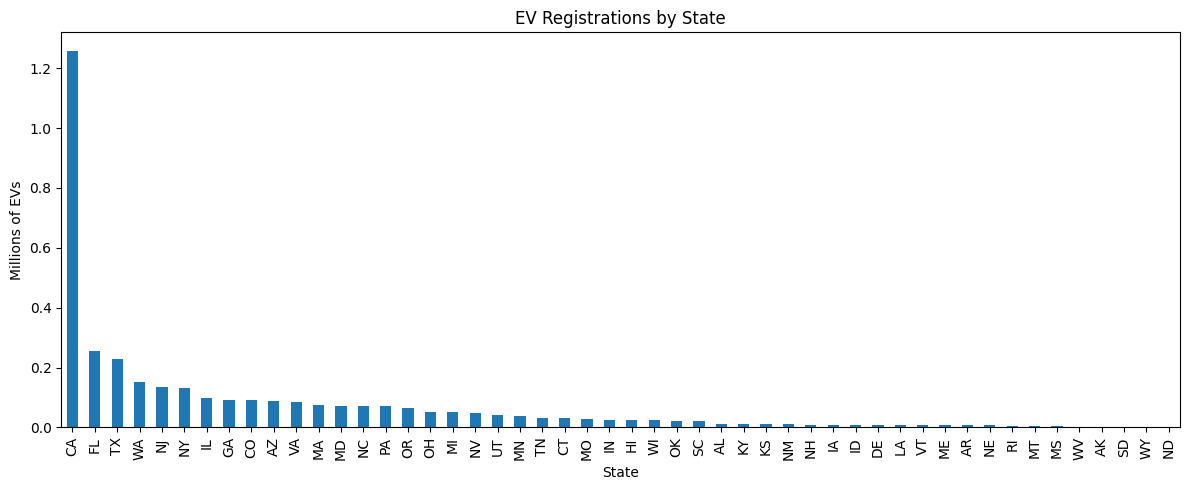

In [40]:
# EDA 2

ev_per_state_millions = ev_per_state / 1_000_000
ax = ev_per_state_millions.plot(kind='bar', figsize=(12, 5), title="EV Registrations by State")
plt.ylabel("Millions of EVs")
plt.tight_layout()
plt.show()



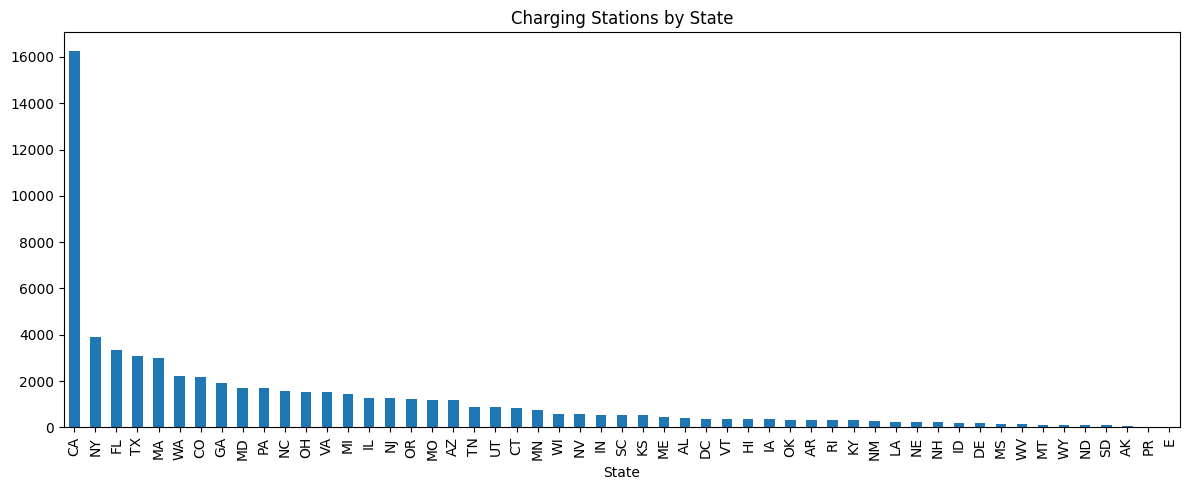

In [41]:
# EDA 3

stations_per_state = df.groupby('State').size().sort_values(ascending=False)
stations_per_state.plot(kind='bar', figsize=(12, 5), title="Charging Stations by State")
plt.tight_layout()
plt.show()

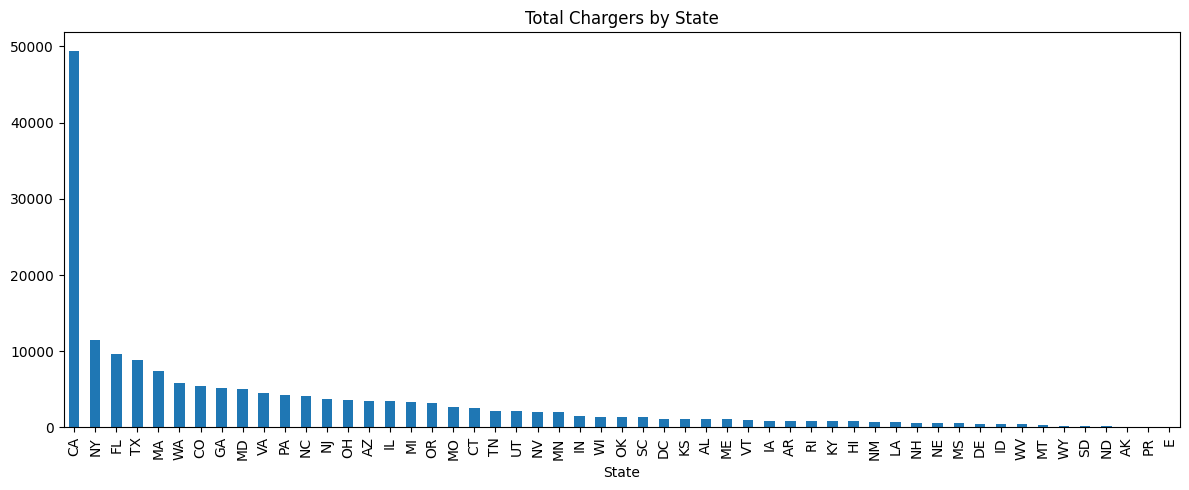

In [42]:
# EDA 4

chargers_per_state = df.groupby('State')['Total_Chargers'].sum().sort_values(ascending=False)
chargers_per_state.plot(kind='bar', figsize=(12, 5), title="Total Chargers by State")
plt.tight_layout()
plt.show()

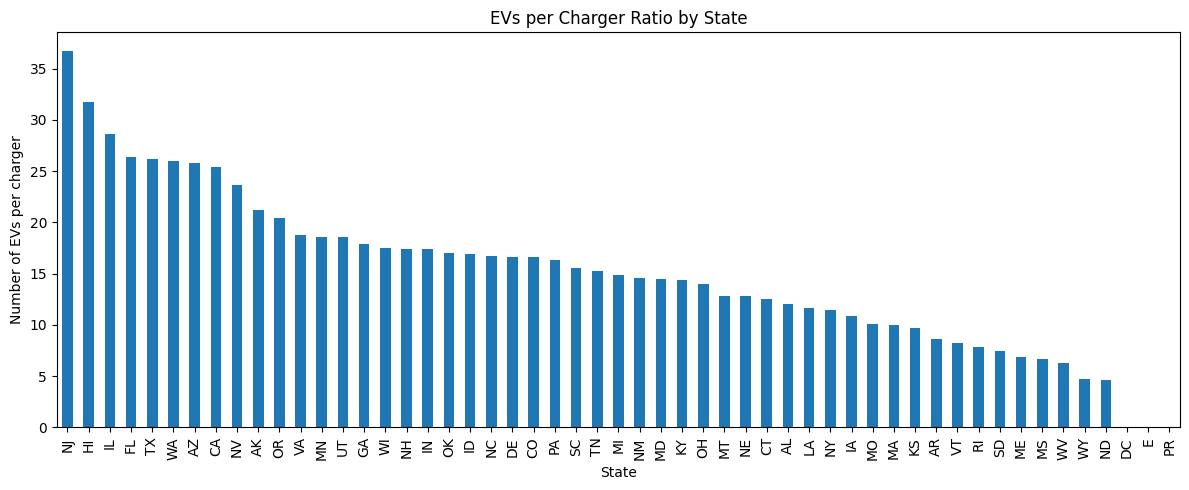

In [43]:
# EDA 5

evs = state_df.groupby('State')['EV_Registrations'].first()
chargers = df.groupby('State')['Total_Chargers'].sum()
ev_charger_ratio = (evs / chargers).sort_values(ascending=False)
ev_charger_ratio.plot(kind='bar', figsize=(12, 5), title="EVs per Charger Ratio by State")
plt.ylabel("Number of EVs per charger")
plt.tight_layout()
plt.show()

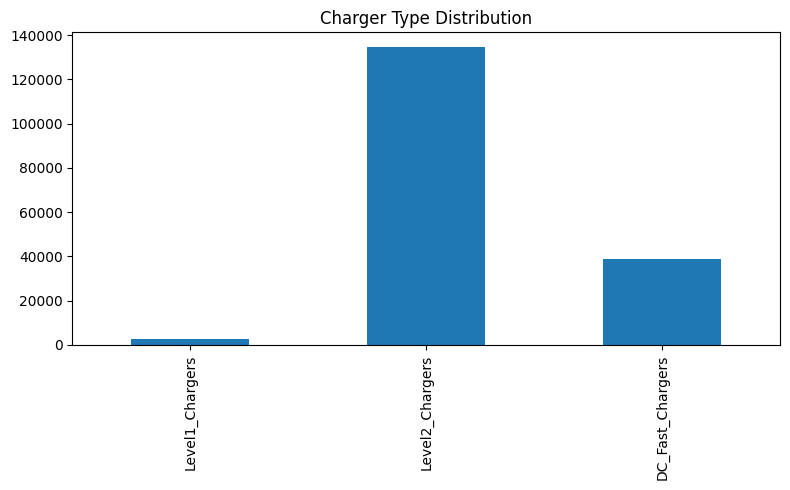

In [44]:
# EDA 6 

df[['Level1_Chargers', 'Level2_Chargers', 'DC_Fast_Chargers']].sum().plot(
    kind='bar', title="Charger Type Distribution", figsize=(8, 5))
plt.tight_layout()
plt.show()

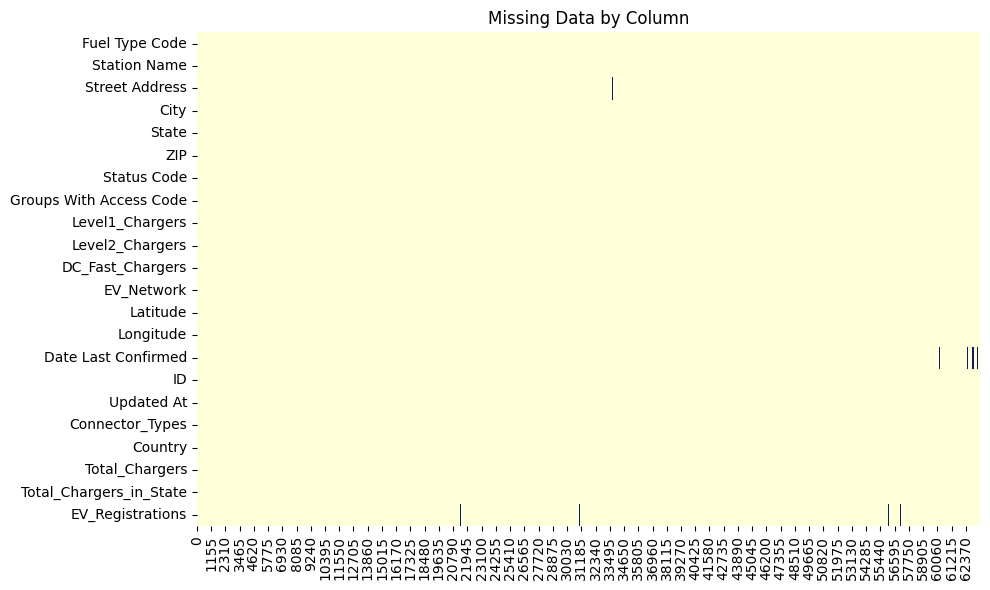

In [45]:
# EDA 7

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap="YlGnBu")
plt.title("Missing Data by Column")
plt.tight_layout()
plt.show()


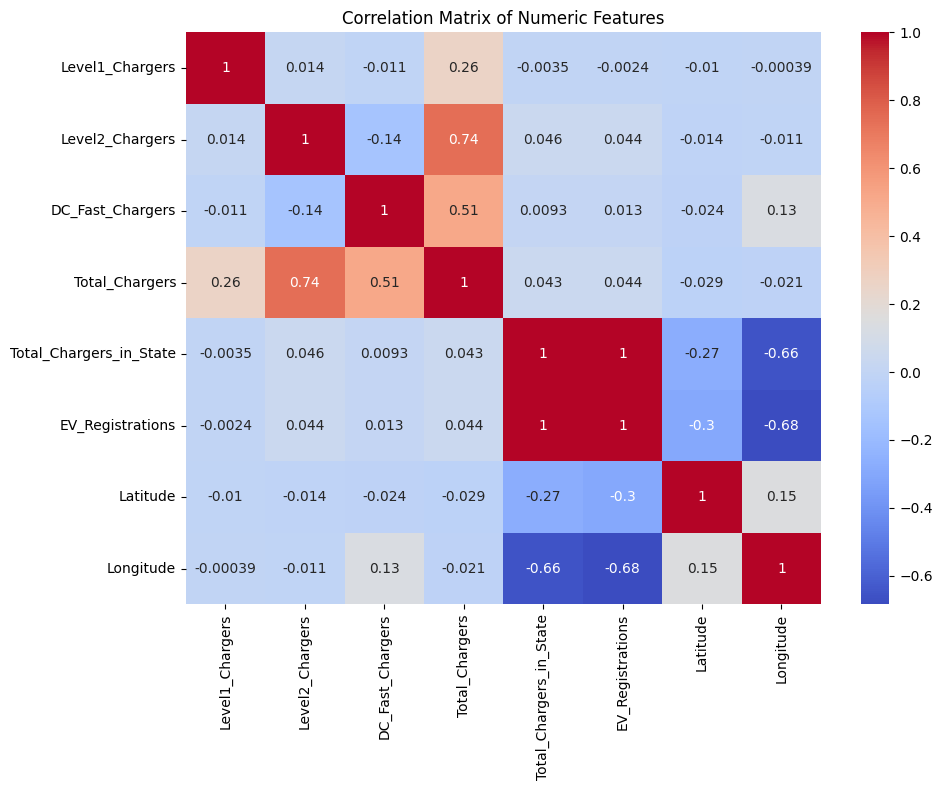

In [46]:
# EDA 8

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [47]:
# EDA 9

outliers = ev_charger_ratio[ev_charger_ratio > ev_charger_ratio.quantile(0.95)]
print("Worst 5% of EV to Charger Ratios:\n", outliers.head())

Worst 5% of EV to Charger Ratios:
 State
NJ    36.707437
HI    31.718362
IL    28.637619
dtype: float64


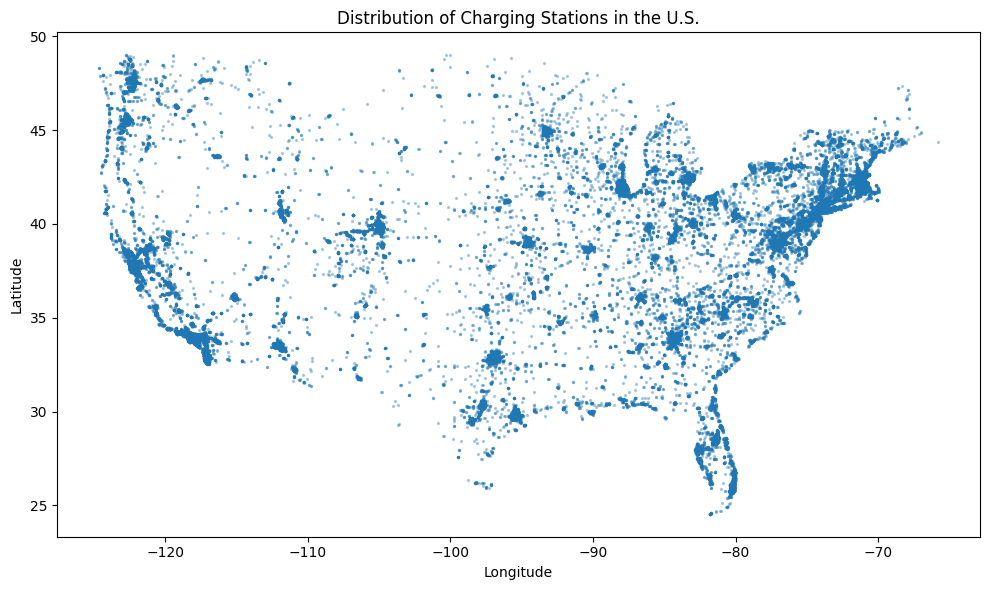

In [48]:
# EDA 10

df_clean = df[(df['Latitude'].between(24, 50)) & (df['Longitude'].between(-125, -65))]


plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Longitude'], df_clean['Latitude'], alpha=0.3, s=2)
plt.title("Distribution of Charging Stations in the U.S.")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Load dataset
df = pd.read_csv("Merged_EV_Charging_Stations.csv")

# Select relevant features for clustering
features = ['Total_Chargers', 'Level2_Chargers', 'DC_Fast_Chargers']
df = df[features].dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

/var/folders/gy/0rmdwj1x791d0hw3cznd4snc0000gn/T/ipykernel_77633/1733964128.py:10: DtypeWarning: Columns (5,9,12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Merged_EV_Charging_Stations.csv")


Since we were clustering charging stations based on variables like Total_Chargers and DC_Fast_Chargers, K-Means gave us a fast and interpretable way to group stations by their infrastructure.

K-Means revealed three main types of stations: small setups (few chargers), mid range stations, and high capacity fast charging hubs.


/var/folders/gy/0rmdwj1x791d0hw3cznd4snc0000gn/T/ipykernel_77633/1874380518.py:11: DtypeWarning: Columns (5,9,12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Merged_EV_Charging_Stations.csv")


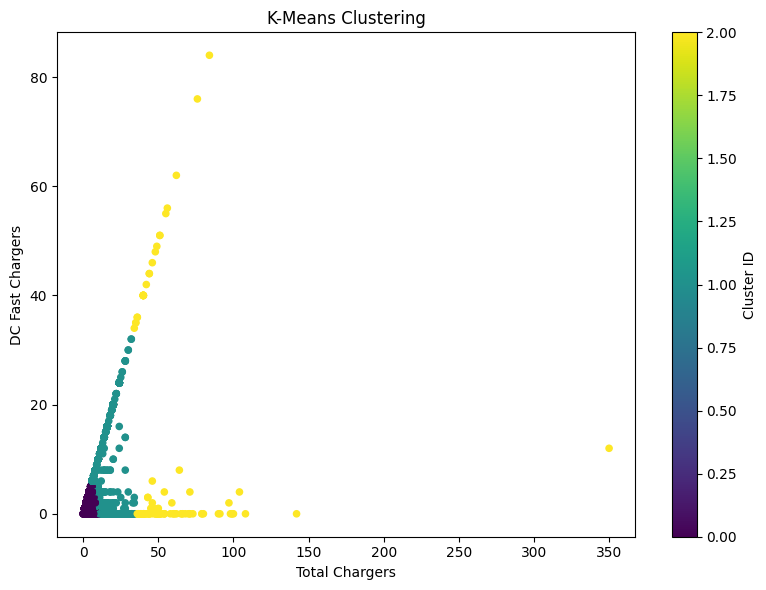

In [33]:
# -------------------------
# K-Means
# -------------------------


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("Merged_EV_Charging_Stations.csv")

# Create dataframe of Total_Chargers and DC_Fast_Chargers
df_charger_config = df[['Total_Chargers', 'DC_Fast_Chargers']].dropna()

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
# Apply clustering to the charger configurations and store the assigned cluster for each station
df_charger_config['Cluster'] = kmeans.fit_predict(df_charger_config)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(df_charger_config['Total_Chargers'], df_charger_config['DC_Fast_Chargers'], c=df_charger_config['Cluster'], cmap='viridis', s=20)
plt.title('K-Means Clustering')
plt.xlabel('Total Chargers')
plt.ylabel('DC Fast Chargers')
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()

# yellow -  Stations with many total chargers, including lots of DC Fast
# green -	Small stations with no or very few DC Fast chargers
# purple -	Moderate stations, maybe a mix of L2 and a few DC Fast



DBSCAN is good for identifying clusters and filtering out outliers or noise, which is useful when exploring data with unknown structure. We applied DBSCAN to charger configuration features to explore the grouping results.

When used on charger configurations (Level2_Chargers, DC_Fast_Chargers), DBSCAN highlighted standard infrastructure clusters and marked unique or rare station types as outliers.

Unlike K-Means, DBSCAN doesn't require specifying the number of clusters. This allowed us to exlpore the results as they were interpreted by the algorithm 

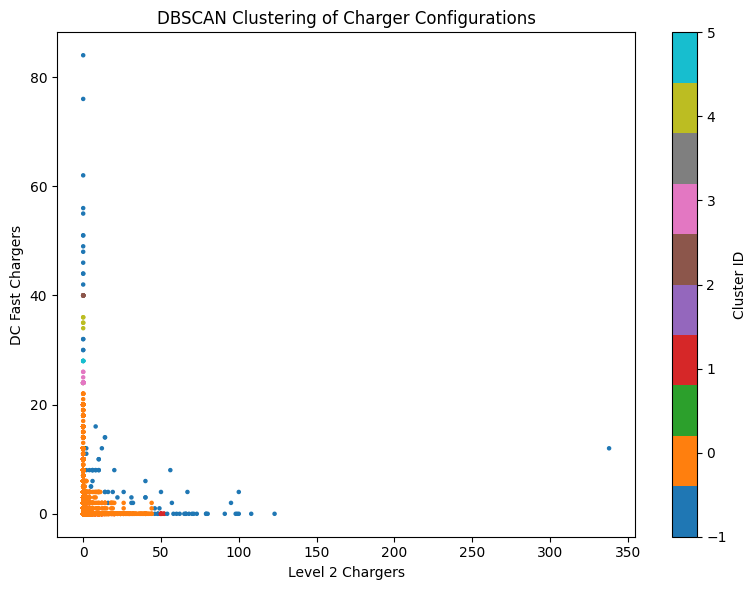

In [38]:
# -------------------------
# DBSCAN Clustering
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


# select charger counts
df_charger_config = df[['Level2_Chargers', 'DC_Fast_Chargers']].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_charger_config)

# Run DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(df_charger_config['Level2_Chargers'], df_charger_config['DC_Fast_Chargers'], c=labels, cmap='tab10', s=5)
plt.title("DBSCAN Clustering of Charger Configurations")
plt.xlabel("Level 2 Chargers")
plt.ylabel("DC Fast Chargers")
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()


# Orange - Most common configuration, usually low L2 and no fast chargers
# Green - Smaller group with a distinct setup (mid-range stations)
# Purple - Possibly stations with higher DC fast chargers
# Pink - Unusual configuration (high DC fast but low L2)
# Gray/Black - outliers that don’t fit into any group 
# Yellow, Blue, etc. - Smaller clusters DBSCAN detected based on density




BIRCH is designed for large datasets and can handle clustering efficiently. Based on our research, it's a strong choice when the dataset is too large for other clustering methods and when processing speed is of concern.

BIRCH cleanly grouped stations into distinct clusters based on charger counts.

It outperformed DBSCAN in terms of clarity, making the results easier to interpret. 

Source: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.Birch.html



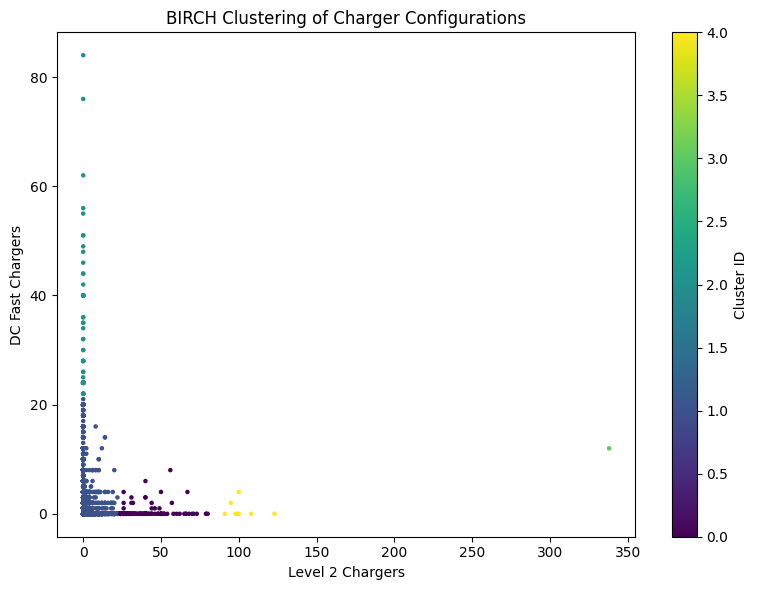

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import Birch
import matplotlib.pyplot as plt

# Select and scale features
features = ['Level2_Chargers', 'DC_Fast_Chargers']
df_charger_config = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_charger_config)

# Apply BIRCH
birch = Birch(n_clusters=5)
labels = birch.fit_predict(X_scaled)

# Plot 
plt.figure(figsize=(8, 6))
plt.scatter(df_charger_config['Level2_Chargers'], df_charger_config['DC_Fast_Chargers'], c=labels, cmap='viridis', s=5)
plt.title("BIRCH Clustering of Charger Configurations")
plt.xlabel("Level 2 Chargers")
plt.ylabel("DC Fast Chargers")
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()


# purple - Bottom left Small stations — low L2 and no DC fast
# dark blue - Just above Cluster 0  Mostly L2 chargers with some DC fast
# teal/green - Vertical spread High DC fast, low L2 (highway fast hubs)
# yellow - Right side High L2 charger count, few or no DC fast — e.g. garage or campus style
# bright green - Far top-right corner Large outlier — likely a major charging facility (Tesla)

